In [1]:
!pip install xgboost

In [1]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor



# 2. LOAD DATA

df = pd.read_csv("pre-processed_data.csv")


# 3. DEFINE FEATURES & TARGET

features = ['Hour','Total Load MW','hydro','solar','coal','wind']
target = 'Carbon intensity gCO2eq/kWh (direct)'

X = df[features]
y = df[target]

# 4. TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. SCALING (ONLY FOR LINEAR REGRESSION)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 6. LINEAR REGRESSION MODEL

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_train_pred_lr = lr.predict(X_train_scaled)
y_test_pred_lr = lr.predict(X_test_scaled)

# 7. XGBOOST MODEL (NO SCALING)

xgb = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

y_train_pred_xgb = xgb.predict(X_train)
y_test_pred_xgb = xgb.predict(X_test)

# 8. EVALUATION FUNCTION

def evaluate(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

In [2]:
# 9. MODEL COMPARISON

results = []

# Linear Regression
results.append({
    "Model": "Linear Regression",
    **{"Train_"+k:v for k,v in evaluate(y_train, y_train_pred_lr).items()},
    **{"Test_"+k:v for k,v in evaluate(y_test, y_test_pred_lr).items()}
})

# XGBoost
results.append({
    "Model": "XGBoost",
    **{"Train_"+k:v for k,v in evaluate(y_train, y_train_pred_xgb).items()},
    **{"Test_"+k:v for k,v in evaluate(y_test, y_test_pred_xgb).items()}
})

results_df = pd.DataFrame(results)
print(results_df)

               Model  Train_R2  Train_RMSE  Train_MAE   Test_R2  Test_RMSE  \
0  Linear Regression  0.990174    6.818976   5.179799  0.990575   6.770389   
1            XGBoost  0.999061    2.107518   1.514776  0.998115   3.027794   

   Test_MAE  
0  5.159413  
1  2.166730  


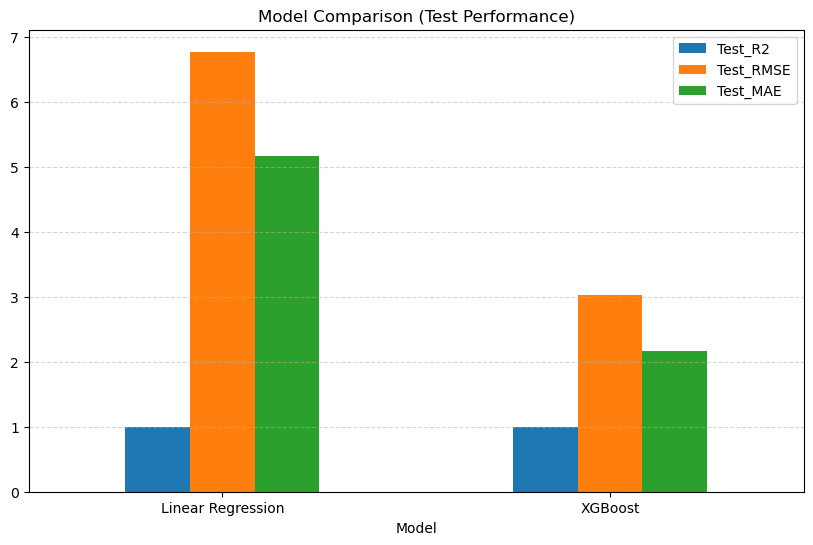

In [3]:
# 10. VISUALIZATION


#  Model Performance Comparison
results_df.set_index("Model")[["Test_R2","Test_RMSE","Test_MAE"]].plot(
    kind='bar',
    figsize=(10,6)
)
plt.title("Model Comparison (Test Performance)")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

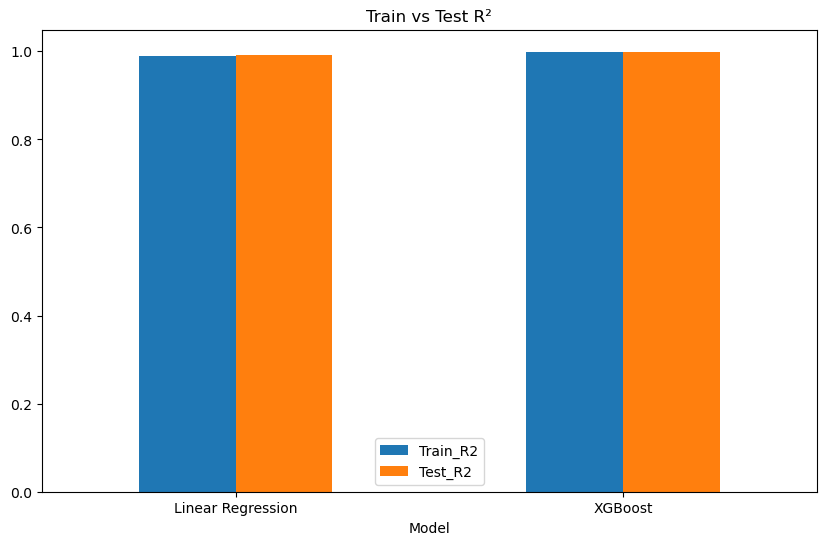

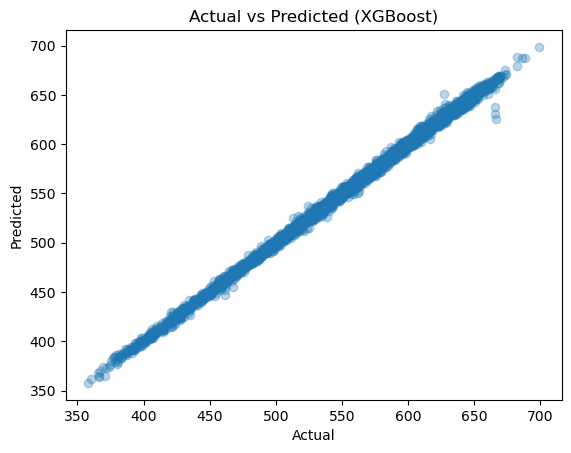

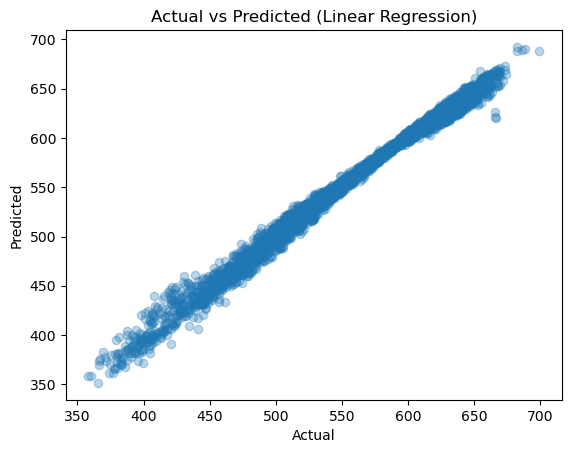

In [4]:
# Train vs Test (Overfitting Check)
results_df.set_index("Model")[["Train_R2","Test_R2"]].plot(
    kind='bar',
    figsize=(10,6)
)
plt.title("Train vs Test R²")
plt.xticks(rotation=0)
plt.show()

#  Actual vs Predicted (XGBoost)
plt.scatter(y_test, y_test_pred_xgb, alpha=0.3)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (XGBoost)")
plt.show()



plt.scatter(y_test, y_test_pred_lr, alpha=0.3)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

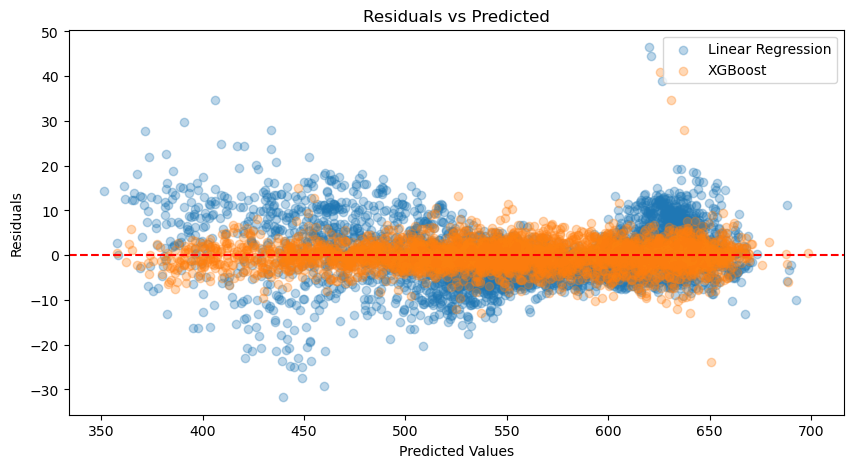

In [5]:
#  Residual Plot (XGBoost)
residuals_XGB = y_test - y_test_pred_xgb

# Residual Plot ( lr_Regression)
residuals_lr = y_test - y_test_pred_lr

plt.figure(figsize=(10,5))

plt.scatter(y_test_pred_lr, residuals_lr, alpha=0.3, label='Linear Regression')
plt.scatter(y_test_pred_xgb, residuals_XGB, alpha=0.3, label='XGBoost')

plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.legend()
plt.show()

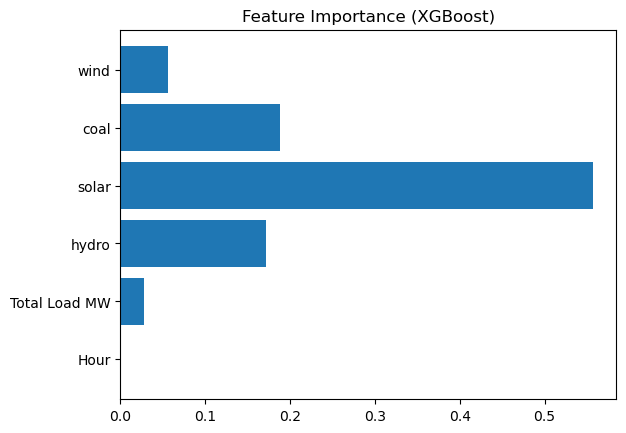

In [6]:
#  Feature Importance (XGBoost)
importances = xgb.feature_importances_

plt.barh(features, importances)
plt.title("Feature Importance (XGBoost)")
plt.show()




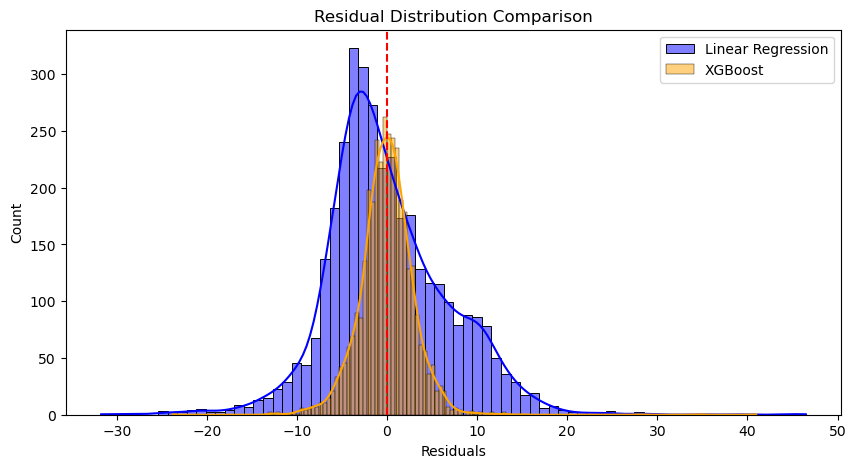

In [7]:
# Residual Distribution

plt.figure(figsize=(10,5))

sns.histplot(residuals_lr, kde=True, label='Linear Regression', color='blue')
sns.histplot(residuals_XGB, kde=True, label='XGBoost', color='orange')

plt.axvline(0, color='red', linestyle='--')
plt.title("Residual Distribution Comparison")
plt.xlabel("Residuals")
plt.legend()
plt.show()

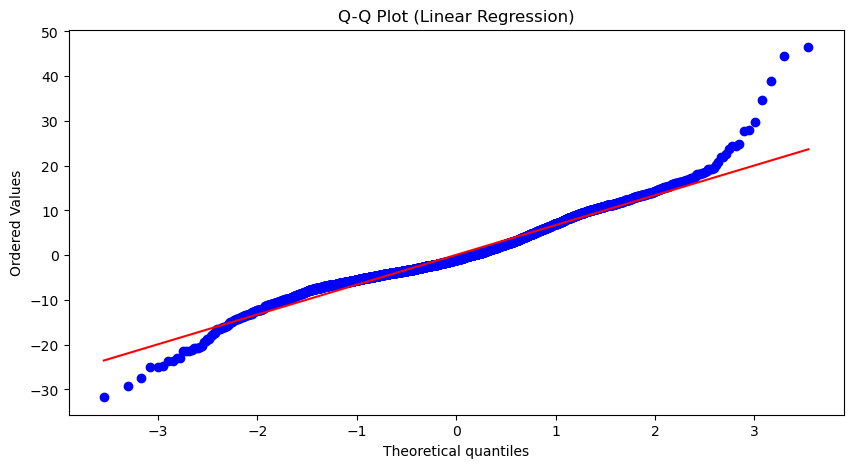

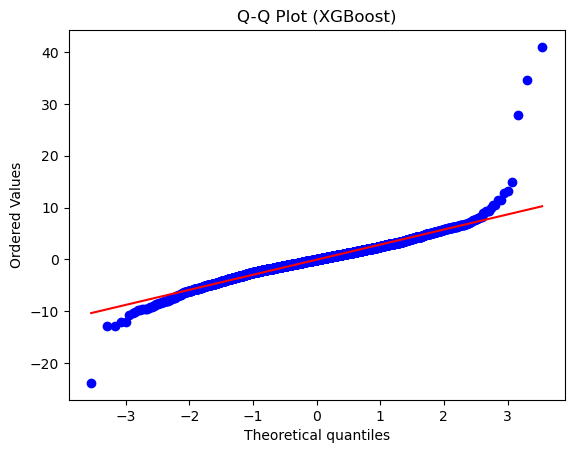

In [9]:
# Q-Q plot
plt.figure(figsize=(10,5))

stats.probplot(residuals_lr, dist="norm", plot=plt)
plt.title("Q-Q Plot (Linear Regression)")
plt.show()

stats.probplot(residuals_XGB, dist="norm", plot=plt)
plt.title("Q-Q Plot (XGBoost)")
plt.show()

In [13]:
import joblib

joblib.dump(xgb, "xgboost_model.pkl")

['xgboost_model.pkl']

In [12]:
joblib.dump(lr, "linear_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']